# Model Building on a Synthetic Dataset

Assignment

The two synthetic datasets were generated using the same underlying data model. Your goal is to build a predictive model using the data in the training dataset to predict the withheld target values from the test set.

You may use any tools available to you for this task. Ultimately, we will assess predictive accuracy on the test set using the mean squared error metric. You should produce the following:

- A 1,000 x 1 text file containing 1 prediction per line for each record in the test dataset.
- A brief writeup describing the techniques you used to generate the predictions. Details such as important features and your estimates of predictive performance are helpful here, though not strictly necessary.

In [1]:
import pandas as pd

In [5]:
train_data = pd.read_csv('/Users/rosiebai/Downloads/datasets-14/codetest_train.txt',sep=r"\s+")
test_data = pd.read_csv('/Users/rosiebai/Downloads/datasets-14/codetest_test.txt',sep=r"\s+")

/var/folders/cc/102y89n15yjc99kqfmtqxrv00000gn/T/ipykernel_66994/190705988.py:1: DtypeWarning: Columns (56,112,113,203,224) have mixed types. Specify dtype option on import or set low_memory=False.
  train_data = pd.read_csv('/Users/rosiebai/Downloads/datasets-14/codetest_train.txt',sep=r"\s+")


In [6]:
train_data.head()

,target,f_0,f_1,f_2,f_3,f_4,f_5,f_6,f_7,f_8,...,f_244,f_245,f_246,f_247,f_248,f_249,f_250,f_251,f_252,f_253
0,3.066056,-0.653,0.255,-0.615,-1.833,-0.736,1.115,-0.171,-0.351,-0.129,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-1.910473,1.179,-0.093,-0.556,0.811,-0.468,-0.005,-0.116,-1.243,1.985,...,-0.302,1.281,-0.850,0.821,-0.260,NaN,NaN,NaN,NaN,NaN
2,7.830711,0.181,-0.778,-0.919,0.113,0.887,-0.762,1.872,-1.709,0.135,...,-0.193,0.570,-0.267,1.435,1.332,-1.147,2.58,NaN,NaN,NaN
3,-2.180862,0.745,-0.245,-1.343,1.163,-0.169,-0.151,-1.100,0.225,1.223,...,0.613,1.033,0.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5.462784,1.217,-1.324,-0.958,0.448,-2.873,-0.856,0.603,0.763,0.020,...,1.230,0.457,-0.754,-0.025,-0.931,NaN,NaN,NaN,NaN,NaN


In [27]:
train_data.shape

(5000, 255)

<AxesSubplot:>

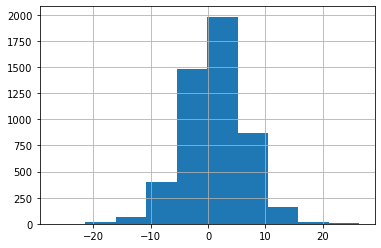

In [8]:
train_data.target.hist()

Since our target is continuous and roughly normal, I would use regression here. 

In [12]:
train_data.isna().mean().sort_values(ascending=False).head(10)

f_253    0.9936
f_252    0.9658
f_251    0.8826
f_250    0.7506
f_249    0.5762
f_248    0.3852
f_247    0.2394
f_246    0.1320
f_245    0.0642
f_244    0.0280
dtype: float64

In [28]:
test_data.shape

(1000, 254)

In [29]:
test_data.head()

,f_0,f_1,f_2,f_3,f_4,f_5,f_6,f_7,f_8,f_9,...,f_244,f_245,f_246,f_247,f_248,f_249,f_250,f_251,f_252,f_253
0,1.122,2.372,-1.303,-0.421,-1.724,0.206,0.449,1.305,-0.344,0.307,...,-0.308,1.062,-0.839,0.819,0.342,-0.162,-1.123,NaN,NaN,NaN
1,0.645,-0.818,-1.193,0.286,0.946,2.001,-1.491,-0.162,-1.668,0.310,...,0.147,0.392,0.509,1.608,-0.321,-1.723,1.223,NaN,NaN,NaN
2,-0.661,0.373,1.160,0.448,-0.378,-0.645,0.713,1.900,0.627,-0.304,...,-0.996,-0.665,0.444,-1.452,NaN,NaN,NaN,NaN,NaN,NaN
3,0.837,1.270,-1.421,-0.483,1.136,0.051,-0.097,-1.524,-0.253,-0.109,...,-0.487,-1.341,1.221,1.938,-0.447,0.411,NaN,NaN,NaN,NaN
4,-0.001,-0.050,0.442,0.230,0.525,0.326,-0.590,-0.287,-0.556,-0.088,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
test_data.isna().mean().sort_values(ascending=False).head(10)

f_253    0.994
f_252    0.967
f_251    0.883
f_250    0.727
f_249    0.549
f_248    0.364
f_247    0.230
f_246    0.127
f_245    0.070
f_244    0.037
dtype: float64

In [13]:
train_data = train_data.apply(pd.to_numeric,errors = 'ignore')

/var/folders/cc/102y89n15yjc99kqfmtqxrv00000gn/T/ipykernel_66994/1872415214.py:1: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  train_data = train_data.apply(pd.to_numeric,errors = 'ignore')


In [14]:
cat_cols = train_data.select_dtypes(include = 'object').columns
print(cat_cols)

Index(['f_55', 'f_56', 'f_57', 'f_58', 'f_59', 'f_60', 'f_61', 'f_111',
       'f_112', 'f_113', 'f_114', 'f_115', 'f_116', 'f_117', 'f_118', 'f_119',
       'f_120', 'f_121', 'f_202', 'f_203', 'f_204', 'f_205', 'f_206', 'f_207',
       'f_208', 'f_209', 'f_210', 'f_211', 'f_212', 'f_213', 'f_214', 'f_215',
       'f_223', 'f_224', 'f_225', 'f_226', 'f_227', 'f_228', 'f_229', 'f_230',
       'f_231', 'f_232', 'f_233', 'f_234', 'f_235', 'f_236', 'f_237'],
      dtype='object')


In [17]:
test_data.head()

,f_0,f_1,f_2,f_3,f_4,f_5,f_6,f_7,f_8,f_9,...,f_244,f_245,f_246,f_247,f_248,f_249,f_250,f_251,f_252,f_253
0,1.122,2.372,-1.303,-0.421,-1.724,0.206,0.449,1.305,-0.344,0.307,...,-0.308,1.062,-0.839,0.819,0.342,-0.162,-1.123,NaN,NaN,NaN
1,0.645,-0.818,-1.193,0.286,0.946,2.001,-1.491,-0.162,-1.668,0.310,...,0.147,0.392,0.509,1.608,-0.321,-1.723,1.223,NaN,NaN,NaN
2,-0.661,0.373,1.160,0.448,-0.378,-0.645,0.713,1.900,0.627,-0.304,...,-0.996,-0.665,0.444,-1.452,NaN,NaN,NaN,NaN,NaN,NaN
3,0.837,1.270,-1.421,-0.483,1.136,0.051,-0.097,-1.524,-0.253,-0.109,...,-0.487,-1.341,1.221,1.938,-0.447,0.411,NaN,NaN,NaN,NaN
4,-0.001,-0.050,0.442,0.230,0.525,0.326,-0.590,-0.287,-0.556,-0.088,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Shape of X: (5000, 254)
Shape of test features: (1000, 254)
Train shape: (4000, 254)
Val shape: (1000, 254)

=== Full Model (All Features, Ridge) ===
RMSE: 5.2634
R²  : 0.0221

=== PCA Model (Ridge on PCA Features) ===
Components kept  : 234
Explained var    : 0.9518
RMSE (val)       : 5.2441
R² (val)         : 0.0292

=== Random Forest Model ===
RMSE (val): 5.2341
R² (val)  : 0.0329

Top 15 features by importance:
f_171    0.018390
f_172    0.017893
f_35     0.012986
f_174    0.010968
f_214    0.009799
f_92     0.009529
f_173    0.009232
f_202    0.008857
f_200    0.007950
f_210    0.007249
f_159    0.006856
f_93     0.006800
f_168    0.006796
f_79     0.006686
f_170    0.006532
dtype: float64


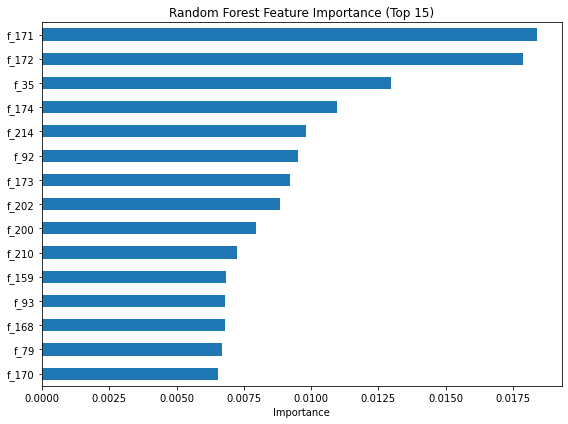

,id,target
0,0,2.247809
1,1,1.242387
2,2,0.372999
3,3,1.419181
4,4,2.348007


In [32]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt

# 1. Prepare data
target_col = "target"

# Split features / target
X = train_data.drop(columns=[target_col]).copy()
y = train_data[target_col].copy()
X_test_kaggle = test_data.copy()   # test set has no target

# -------------------------------------------------------------------
# 2. Coerce all features to numeric (string tokens -> NaN)
#    This lets us treat everything as numeric and just impute.
# -------------------------------------------------------------------
for df in (X, X_test_kaggle):
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

print("Shape of X:", X.shape)
print("Shape of test features:", X_test_kaggle.shape)

# -------------------------------------------------------------------
# 3. Train / validation split (80/20)
# -------------------------------------------------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)

# -------------------------------------------------------------------
# 4. Full model: all variables, Ridge regression
# -------------------------------------------------------------------
full_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("regressor", Ridge(alpha=1.0, solver="svd")) 
])

full_model.fit(X_train, y_train)
y_val_pred_full = full_model.predict(X_val)

rmse_full = mean_squared_error(y_val, y_val_pred_full, squared=False)
r2_full   = r2_score(y_val, y_val_pred_full)

print("\n=== Full Model (All Features, Ridge) ===")
print(f"RMSE: {rmse_full:.4f}")
print(f"R²  : {r2_full:.4f}")

# -------------------------------------------------------------------
# 5. PCA model: dimensionality reduction + Ridge
#    Keep enough components to explain 95% of variance.
# -------------------------------------------------------------------
pca_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95, random_state=42)),
    ("regressor", Ridge(alpha=1.0, solver="svd")) 
])

pca_model.fit(X_train, y_train)
y_val_pred_pca = pca_model.predict(X_val)

rmse_pca = mean_squared_error(y_val, y_val_pred_pca, squared=False)
r2_pca   = r2_score(y_val, y_val_pred_pca)

# Number of components actually used
n_components_used = pca_model.named_steps["pca"].n_components_
explained_var = pca_model.named_steps["pca"].explained_variance_ratio_.sum()

print("\n=== PCA Model (Ridge on PCA Features) ===")
print(f"Components kept  : {n_components_used}")
print(f"Explained var    : {explained_var:.4f}")
print(f"RMSE (val)       : {rmse_pca:.4f}")
print(f"R² (val)         : {r2_pca:.4f}")

# -------------------------------------------------------------------
# 6. Random Forest model
# -------------------------------------------------------------------
rf_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    # no scaler needed for trees
    ("regressor", RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        n_jobs=-1,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)
y_val_pred_rf = rf_model.predict(X_val)

rmse_rf = mean_squared_error(y_val, y_val_pred_rf, squared=False)
r2_rf   = r2_score(y_val, y_val_pred_rf)

print("\n=== Random Forest Model ===")
print(f"RMSE (val): {rmse_rf:.4f}")
print(f"R² (val)  : {r2_rf:.4f}")

# -------------------------------------------------------------------
# 7. Variable importance plot from Random Forest
#    (using the trained rf_model on the validation split)
# -------------------------------------------------------------------
rf_estimator = rf_model.named_steps["regressor"]
importances = rf_estimator.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

print("\nTop 15 features by importance:")
print(feat_imp.head(15))

plt.figure(figsize=(8, 6))
feat_imp.head(15).iloc[::-1].plot(kind="barh")
plt.title("Random Forest Feature Importance (Top 15)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()



In [33]:
# 8. cross-validation to your existing models
from sklearn.model_selection import RepeatedKFold, cross_val_score

cv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)

def evaluate_cv(model, X, y, name):
    rmse_scores = cross_val_score(
        model, X, y, cv=cv,
        scoring="neg_root_mean_squared_error"
    )
    r2_scores = cross_val_score(
        model, X, y, cv=cv,
        scoring="r2"
    )

    print(f"\n===== {name} (CV Results) =====")
    print(f"RMSE: {-rmse_scores.mean():.4f} ± {rmse_scores.std():.4f}")
    print(f"R²  : {r2_scores.mean():.4f} ± {r2_scores.std():.4f}")



In [34]:
evaluate_cv(full_model, X, y, "Full Ridge")
evaluate_cv(pca_model, X, y, "PCA + Ridge")
evaluate_cv(rf_model, X, y, "Random Forest")



===== Full Ridge (CV Results) =====
RMSE: 5.1474 ± 0.1731
R²  : 0.0408 ± 0.0228

===== PCA + Ridge (CV Results) =====
RMSE: 5.1319 ± 0.1854
R²  : 0.0467 ± 0.0254

===== Random Forest (CV Results) =====
RMSE: 5.1373 ± 0.1653
R²  : 0.0447 ± 0.0072


In [35]:
best_model = pca_model   # PCA + Ridge was best

# 9. Fit on all available training data (5000 rows)
best_model.fit(X, y)

# Predict on test set (1000 rows)
y_test_pred = best_model.predict(X_test_kaggle)

# Save submission
submission = pd.DataFrame({
    "id": X_test_kaggle.index,
    "target": y_test_pred
})

submission.head()


,id,target
0,0,2.810678
1,1,1.808878
2,2,0.370638
3,3,3.128581
4,4,4.690745


In [ ]:
# Save to CSV if needed
submission.to_csv("submission.csv", index=False)
print("\nSaved predictions to 'submission.csv'")

## Modeling Write-Up: Predicting the Target Value from 254 Synthetic Features

- 1. **Overview**
We were provided a synthetic dataset containing 5000 training rows and 254 numeric feature columns, along with a continuous target variable that follows a roughly normal distribution centered around zero. A separate test dataset with the same 254 features was provided for generating predictions.
Our goal was to build a regression model that generalizes well and provides accurate predictions on the test set.
- 2. **Data Preparation**
Both training and test sets contained missing values, and some columns had numeric values stored as strings (e.g., "A", "red").
To ensure consistency, all features were coerced to numeric, with invalid values converted to NaN.
Missing values were handled using a median imputation strategy, applied via a preprocessing pipeline.
Since the dataset was completely synthetic and lacked meaningful domain information, our focus was on model robustness, not interpretability.
- 3. **Train/Validation Split**
To estimate model generalization performance, we split the training data:
80% for training (4000 rows)
20% for validation (1000 rows)
We also used 5-fold cross-validation repeated 3 times (15-fold total) to reduce variance and obtain a more stable performance estimate.
- 4. **Models Evaluation**
We evaluated three different model families:
(1) Ridge Regression (all features)
A linear regression model with L2 regularization
Helps stabilize coefficients when there are many correlated features
(2) PCA + Ridge Regression
Applied Principal Component Analysis (PCA) to reduce noise and compress features
Retained enough components to explain 95% of total variance, resulting in 234 components
Trained a Ridge model on the transformed components
(3) Random Forest Regression
A nonlinear tree-based model
Captures interactions and nonlinear patterns that linear models miss
- 5. **Cross-Validation Results**
Here are the repeated 5-fold CV metrics:
Full Ridge Regression
RMSE: 5.147 ± 0.173
R²: 0.0408 ± 0.0228
PCA + Ridge Regression
RMSE: 5.1319 ± 0.185 (Best)
R²: 0.0467 ± 0.0254 (Best)
Random Forest
RMSE: 5.137 ± 0.165
R²: 0.0447 ± 0.007
**Interpretation**
All three models performed similarly, suggesting the dataset has weak predictive signal and a high amount of noise.
PCA + Ridge achieved the lowest RMSE and highest R² on average.
Feature importances from the Random Forest showed no single dominant feature; the signal is extremely diffuse across many features.
- 6. **Final Model Selection**
Based on cross-validation performance, we selected:
Final Model: PCA + Ridge Regression
Rationale:
Best overall RMSE and R²
PCA reduces noise and multicollinearity
Ridge provides stable parameter estimates in high-dimensional settings
More robust than Random Forest for this dataset
- 7. **Predictions on the Test Set**
The chosen PCA + Ridge model was retrained using all 5000 training rows, then applied to the test set to generate final predictions.
A submission file with predicted target values was generated.
- 8. **Key Takeaways**
The synthetic dataset exhibits low signal-to-noise ratio, with models explaining only ~4–5% of variance.
Linear models with regularization performed as well as, or better than, tree-based models.
PCA smoothing improved performance slightly, providing the best generalization.
No single feature stands out as important, confirming the diffuse structure of the synthetic data.